# USB-6289 — how to use the driver

Same order as before: the simplest thing first, the hardest last. Every
function is explained where it is **first used**.

**Wiring** — a loopback plus the rubidium:

| signal | terminal | ground |
|---|---|---|
| AO 0 → AI 0 | 15 → 1 | AO GND 16 → AI GND 3 |
| 1 pps → PFI 9 | 83 | D GND 82 |

**Restart the kernel after editing the driver.** Python caches imported
modules, so an edited file has no effect until you do. This has caused more
confusion in this project than any real bug.

## 0. Imports

The driver is three files, split by job:

| module | holds | needs hardware? |
|---|---|---|
| `usb6289` | `USB6289`, the instrument you construct | yes |
| `postprocess` | reading and analysing recorded runs | **no** — numpy only |
| `livescope` | viewing a run while it is being written | **no** — numpy only |

In [32]:
import sys, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import nidaqmx
from scipy.interpolate import interp1d

from NIUSB_6289_v2.usb6289 import USB6289
from NIUSB_6289_v2.postprocess import(load_long_run, load_segment, channels_of, edge_report, clean_edges, times_from_edges)

from NIUSB_6289_v2.livescope import RunFiles

## 1. Connect

```python
USB6289(name, device="Dev1")
```

* `name` must be unique in the session — a second `USB6289("daq")` raises.
  Re-running this cell needs `daq.close()` first.
* `device` is the DAQmx name from NI MAX.

On construction the driver **asks the board what it is** — channel counts,
counters, maximum rates, available input ranges — and builds its validators
from the answer rather than from a data sheet.

The tree it gives you:

```
daq                     the board
├── daq.ai              analog INPUT  task   (one clock, one trigger)
│   ├── daq.ai.ai0 … ai31         32 pins
│   └── daq.ai.channels           the same 32, as a group
├── daq.pps             the 1 pps counter    (no channels: one counter, one job)
├── daq.marker          the event counter    (same mechanism, other wire)
└── daq.ao              analog OUTPUT task   (one clock, one waveform)
    ├── daq.ao.ao0 … ao3          4 pins
    └── daq.ao.channels           the same 4, as a group
```

`pps` and `marker` are **the same mechanism** aimed at different wires: a
counter that records the scan index of every pulse on a PFI line. Aimed at the
rubidium it gives atomic seconds — the *ruler*; aimed at the OPX it gives
*events*. The board has exactly two counters and both are spoken for. A start
trigger needs none: it is not timestamped, it **defines** scan 0.

*Where a setting lives* answers one question — **who does the hardware let
decide it?** Per pin → the channel (`ai0.v_max`, `ao0.dc`). Once per task → the
subsystem (`daq.ai.rate`: there is one ADC, so two inputs cannot have different
rates). Across subsystems → the instrument (`daq.clock_check`, `daq.long_run`).

In [34]:
daq = USB6289("daq", device="Dev1")

Connected to: National Instruments USB-6289 (serial:0x1a3882a, firmware:DriverVersion(major_version=26, minor_version=5, update_version=0)) in 2.70s


---
# 1. Loopback test

AO 0 wired to AI 0 — the board measures its own output. Everything downstream
depends on this.

## 2.1 Constant voltage

### `daq.ai.setup(...)`

```python
ai0, = daq.ai.setup({"ai0": (-2.0, 2.0)}, rate=25_000, duration=0.05)
```

The first argument says which pins are on **and** their range:

| form | meaning |
|---|---|
| `"ai0"` | enable it, leave the range alone |
| `["ai0", "ai3"]` | several |
| `{"ai0": 2.0}` | a number means **± that** |
| `{"ai0": (-0.5, 1.5)}` | a pair means exactly that |

Each input has its own programmable gain, so mixing ranges costs nothing.
`rate` is samples per second **per channel**; `duration` is seconds per
`acquire()`; `trigger` is a terminal to wait for. Enabling is **exclusive** —
pins you do not name are switched off. It **returns the channels**, so
`ai0, =` gets you a handle in one line.

### `daq.ao.setup(...)`

Each output pin has a **role**, because the board can drive it two ways:

| role | meaning |
|---|---|
| `"off"` | not in the task |
| `"dc"` | held at a constant voltage by an untimed write |
| `"wave"` | generating the waveform — **at most one pin**: one AO clock |

`"off"` does *not* zero the pin. An untimed output holds its last value
indefinitely; set `dc(0.0)` first if you want it at zero.

## Loopback test

### Constant voltage

### Where do I plug this in?

Two different questions, two tools.

**The static question** — "which terminal is `ai3`?" The answer never changes;
it is the connector.

| call | returns |
|---|---|
| `daq.pin_of("ai3")` | `10` — accepts `ai3`, `AI 3`, `Dev1/ai3`, `PFI8`, `AI GND` |
| `daq.signal_at(81)` | `'PFI 8/P2.0'` — the inverse: what *is* this terminal? |
| `daq.nearest_ground(15, "AO GND")` | `16` — the ground pin to actually wire to |
| `daq.pinout()` | the whole 128-pin connector, both halves |

`nearest_ground` takes the ground **family** — `"AI GND"`, `"AO GND"`,
`"D GND"` — and which one you use matters: returning a signal through the
wrong ground is how you get a mains hum you cannot explain.

**The live question** — "what do I plug in for what I have configured right
now?" That is `daq.wiring()`, further down. It changes as you enable channels
or move the waveform, and it pairs every signal with its return.

In [ ]:
print("ai3 is on terminal ", daq.pin_of("ai3"))
print("its AI GND is       ", daq.nearest_ground(daq.pin_of("ai3"), "AI GND"))
print("terminal 81 carries ", daq.signal_at(81))

daq.pinout()          # the full connector

In [4]:
# configuration for AnalogInput
ai0, = daq.ai.setup({"ai0": (-2.0, 2.0)}, rate=25_000, duration=0.05)
ao0, = daq.ao.setup(channels_role={"ao0": {"dc": 0.0}})

daq.wiring()

daq: Dev1
  role   channel  connection  terminal  signal  note
  -----  -------  ----------  --------  ------  ------------
  ai     ai0      signal (+)         1  AI 0    -2..+2 V RSE
  ai     ai0      return             3  AI GND
  ao dc  ao0      signal            15  AO 0    held at +0 V
  ao dc  ao0      return            16  AO GND
  1 pps    not set - no atomic time axis. daq.pps.terminal('/Dev1/PFI9') (terminal 83)
  ai trig  none - acquisition starts on task.start()


[{'role': 'ai',
  'channel': 'ai0',
  'connection': 'signal (+)',
  'terminal': 1,
  'signal': 'AI 0',
  'note': '-2..+2 V RSE'},
 {'role': 'ai',
  'channel': 'ai0',
  'connection': 'return',
  'terminal': 3,
  'signal': 'AI GND',
  'note': ''},
 {'role': 'ao dc',
  'channel': 'ao0',
  'connection': 'signal',
  'terminal': 15,
  'signal': 'AO 0',
  'note': 'held at +0 V'},
 {'role': 'ao dc',
  'channel': 'ao0',
  'connection': 'return',
  'terminal': 16,
  'signal': 'AO GND',
  'note': ''}]

### `daq.check(verbose=True, strict=False)`

Returns `(level, where, message)` tuples, empty if all is well; `strict=True`
raises instead. It catches what no single validator can, because the constraint
spans parameters or lives in the hardware:

* `amp + |offset|` against the ±10 V output range
* `rate × channels` against the board's **aggregate** limit
* a DIFF channel whose negative half is separately enabled
* a waveform buffer too large for the onboard FIFO
* a record too large for RAM
* **a trigger terminal that cannot be routed** — it hands the task to DAQmx for
  verification, which programs the clocks without starting them

That last one is the prize: otherwise it surfaces when the run starts, hours in.

In [5]:
daq.check()

daq: 0 error(s), 1 warning(s)
  warning [pps] terminal is not set, so no atomic seconds are recorded. acquire()
                still works, but the time axis is the board's own clock - ~4 s/day
                of drift - and long_run() will refuse to start. Set
                daq.pps.terminal('/Dev1/PFI9') (terminal 83).


[('warning',
  'pps',
  "terminal is not set, so no atomic seconds are recorded. acquire() still works, but the time axis is the board's own clock - ~4 s/day of drift - and long_run() will refuse to start. Set daq.pps.terminal('/Dev1/PFI9') (terminal 83).")]

### The sweep

* `ao0.dc(v)` — applied **immediately**; no clock, nothing to start. Setting
  `dc` on an `"off"` pin promotes it to `"dc"`.
* `time.sleep(0.1)` — let the output settle before measuring.
* `daq.ai.acquire()` — runs **one** acquisition, returns `{channel: array}`.
  This is the only call that touches the AI hardware.

In [6]:
v_min, v_max = -1.0, 1.0
step = 0.5

V = np.arange(v_min, v_max+step, step)

In [7]:
for v in V:
    ao0.dc(v)
    time.sleep(0.1)
    data = daq.ai.acquire()
    trace = data["ai0"]

    print(f"Readed: {trace.shape} samples")
    print(f"Set: {v} V, read: {trace.mean()} V")

ao0.dc(0)

Readed: (1250,) samples
Set: -1.0 V, read: -1.0001016855239868 V
Readed: (1250,) samples
Set: -0.5 V, read: -0.5001289248466492 V
Readed: (1250,) samples
Set: 0.0 V, read: -0.00018230911518912762 V
Readed: (1250,) samples
Set: 0.5 V, read: 0.49987003207206726 V
Readed: (1250,) samples
Set: 1.0 V, read: 0.9998753666877747 V


`daq.ao.channels.dc()` is a **broadcast read** over the `ChannelList` — the
parameter for all four pins at once, instead of asking each in turn.

In [8]:
daq.ao.channels.dc() 

(0.0, 0.0, 0.0, 0.0)

## 2.2 Waveform

Waveform settings live on `daq.ao`, not on the pin, because the board has one
AO clock. Only *which pin carries it* is per-pin.

| parameter | meaning |
|---|---|
| `shape` | `"square"`, `"sine"`, `"triangle"`, `"ramp"` |
| `freq` | Hz — snapped so a whole number of samples fits one period |
| `amp`, `offset` | volts |
| `rate` | DAC update rate — sets edge resolution and buffer length |
| `duty` | square duty cycle |
| `actual_freq` | what you really got after snapping |
| `onboard` | **True if the waveform loops from the board's own memory** |

`onboard` decides whether a long run survives: if the buffer fits the onboard
FIFO the loop needs no USB traffic and a saturated input stream cannot starve
it. If not, it is pushed across USB continuously and will underflow (`-200621`)
— hours later, in the middle of the night.

### Waveform

In [12]:
daq.ao.setup({"ao0": {"wave": 1.0}}, shape="square", freq=100)
ai0, = daq.ai.setup({"ai0": (-2.0, 2.0)}, rate=25_000, duration=5)


### `with daq.ao.generating():`

Equivalent to `start()` … `stop()`, but the stop is **guaranteed even if the
measurement raises** — which matters, because a buffered output otherwise holds
its last value forever. Any `ao` parameter can be overridden for the block and
is restored afterwards: `with daq.ao.generating(freq=200, amp=0.5):`.

In [13]:
with daq.ao.generating():
    data = daq.ai.acquire()

### `trace` and `time_axis`

* `ai0.trace()` — **never measures**. The hardware produced every channel in
  one block and `acquire()` split it into rows; this picks one row. It
  **raises** if there is no scan in hand rather than returning a stale array.
* `daq.ai.time_axis()` — sample index ÷ **actual** rate. The clock divides a
  20 MHz timebase, so what you asked for and what the hardware programmed are
  usually different numbers, and only the second gives a correct axis.

In [16]:
y = ai0.trace()
t = daq.ai.time_axis()

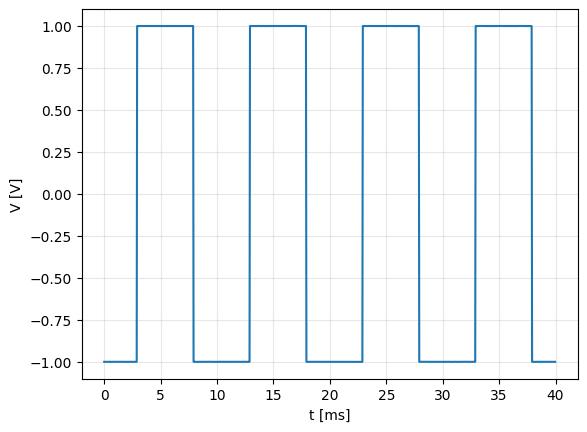

In [17]:
start, end = 0, 1000

plt.plot(t[start:end]*1e3, y[start:end])
plt.xlabel("t [ms]")
plt.ylabel("V [V]")
plt.grid(alpha=0.3)

## 2.3 Waveform, triggered

A **start trigger** makes a task wait for an edge instead of starting
immediately. Point `ai.trigger` and `ao.trigger` at the same line and both fire
on one edge, so the waveform has a known phase at sample 0.

Here both triggers are on **PFI 8**, while the 1 pps arrives separately on
**PFI 9**. So the acquisition starts when the marker fires, and the atomic
seconds are recorded independently — sample 0 is *not* an atomic second, and
the first edge lands somewhere in the first second.

That is the general case and the one worth learning. Putting both on the same
pin is a special case covered below.

### The trigger comes from `ao1`, and that constrains one thing

**AO 1 (pin 31) is wired to PFI 8 (pin 81)**, so the board triggers itself.
Everything in this notebook that waits for a trigger is started by raising
`ao1` — and `daq.ai.set_on_armed(pulse)` does it at the only correct moment,
the instant the AI task is armed and before it blocks on its first read.

```python
def pulse(width=0.02):
    ao1.dc(5.0); time.sleep(width); ao1.dc(0.0)

daq.ai.set_on_armed(pulse)
```

Two rules follow from the wiring, and neither is optional.

**The line must start LOW.** A start trigger fires on a *rising* edge. Set
`ao1` to 5 V before arming and there is no edge to catch — the acquisition
waits until the 60 s read timeout and errors. Every configuration below leaves
it at `0.0`, and every acquisition puts it back.

**The AO task must NOT have a trigger.** This is the one that bites. `ao1` is a
channel *inside* the AO task, so an AO task waiting on PFI 8 could only be
started by a pulse it is itself unable to send — a deadlock, and nothing in
the driver can detect it because nothing knows how you wired the board. So
`daq.ao.setup(...)` no longer takes `trigger=` anywhere in this notebook.

The cost is real and worth naming: **the waveform is no longer sample-locked
to scan 0.** Raising `ao1` rebuilds the AO task (a DC change reconfigures it),
so the waveform effectively restarts when the trigger fires — aligned to
within a millisecond or so, not to within a sample.

If you need true sample-accurate phase-locking, the trigger has to come from
outside the board. The rubidium is right there: point both `ai.trigger` and
`ao.trigger` at `/Dev1/PFI9` and both subsystems wait for the same external
edge, exactly as in the runs recorded earlier in this notebook.

### Which pins can be a trigger, and which can carry the 1 pps?

```python
daq.terminals(physical=True)     # only the ones a cable can reach
daq.terminals(physical=False)    # everything DAQmx will route
```

The board reports **two kinds** of routable terminal, and the difference
decides what each can be used for:

| kind | example | can an external cable reach it? |
|---|---|---|
| **physical** | `/Dev1/PFI8` → terminal 81 | **yes** |
| **internal** | `/Dev1/ai/SampleClock`, `/Dev1/Ctr0InternalOutput` | no — no pin exists |

* `ai.trigger` and `ao.trigger` accept **either**. An internal route is how one
  subsystem triggers another without a wire.
* `pps.terminal` must be **physical** — the rubidium's pulse arrives from
  outside the board, so it needs a pin.

Both parameters validate against this list, so a terminal that cannot be
routed is rejected at set time; and `daq.check()` goes further by handing the
task to DAQmx, which rejects routes that are legal in principle but conflict
with what else is configured.

### What if the trigger and the 1 pps are on *different* pins?

**Nothing breaks — that is the ordinary case.** They are independent settings:

* `ai.trigger` decides *when the acquisition starts*
* `pps.terminal` decides *where the atomic seconds arrive*

Putting both on PFI 8 is a convenience, not a requirement. It buys one thing:
the same edge starts the acquisition and marks an atomic second, so **scan 0
is an atomic second** and the first edge comes back at scan 0.

On separate pins, the first edge lands wherever it lands — somewhere in the
first second — and `times_from_edges` still puts `t = 0` at that first edge.
Samples taken *before* it come out **negative**, which is correct and
deliberate: they happened before the first atomic second you witnessed.

That is often what you want. With `ai.trigger` on the OPX marker and
`pps.terminal` on PFI 9, the first edge tells you exactly how far the next
atomic second was from the start of the shot — which is the number that puts a
QM experiment on the atomic timebase.

**One cost of sharing the pin**, worth knowing: the acquisition then waits for
the next 1 pps edge, so it starts up to 1 s late — and if the rubidium is off
or unplugged, it waits for the 60 s read timeout instead of starting at all.

In [ ]:
daq.terminals()                    # physical: a cable can reach these

# ai.trigger and ao.trigger can also use internal routes:
# daq.terminals(physical=False)

### So where can the 1 pps actually go?

**Any PFI line — PFI 0 to PFI 15.** All sixteen are on the digital connector
and any of them can clock a counter, so the choice is about wiring, not
capability.

`daq.terminals()` lists them with their **ground** pin, and the board is not
even-handed:

```
   /Dev1/PFI0    terminal  73   D GND  82 (9 pins away)
   /Dev1/PFI7    terminal  80   D GND  82 (2 pins away)
   /Dev1/PFI8    terminal  81   D GND  82 (adjacent)
   /Dev1/PFI9    terminal  83   D GND  82 (adjacent)
   /Dev1/PFI15   terminal  95   D GND  94 (adjacent)
```

**PFI 8–15 each sit next to a D GND pin. PFI 0–7 do not** — they all share the
single D GND at pin 82, up to nine screws away.

For an external TTL that matters twice over: a short return loop picks up less,
and two adjacent screws are simply easier to get right at the terminal block at
midnight. So for the rubidium, use **PFI 8–15**.

| line | signal pin | ground pin |
|---|---|---|
| PFI 8 | 81 | 82 |
| PFI 9 | 83 | 82 |
| PFI 10 | 85 | 84 |
| PFI 11 | 87 | 86 |
| PFI 12 | 89 | 88 |

The convention in this driver's docstrings is **PFI 8 for the trigger, PFI 9
for the 1 pps** — arbitrary, but consistent, and `daq.wiring()` prints whatever
you actually chose.

One thing that is *not* a constraint: the counter. `pps.counter` defaults to
`ctr1`, and any PFI line can clock either counter, so the two choices are
independent.

### Is any pin *dedicated* to the trigger, or to the 1 pps?

**No — and that is a property of this board, not an omission.** On an M Series
device every PFI line is fully routable to every timing signal: start trigger,
sample clock, counter source, counter gate. "Which pin is the trigger pin?" has
no answer beyond *the one you chose*.

(It was a real question on the older **E Series**, where PFI 0 *was* the AI
start trigger and nothing else. That is not this board — if you are reading an
older manual or an older script, that is the difference.)

What the manual *does* define is the pin each counter uses **when you do not
say otherwise**:

| line | default role | line | default role |
|---|---|---|---|
| PFI 3 | CTR 1 SRC | PFI 10 | CTR 0 AUX |
| PFI 4 | CTR 1 GATE | PFI 11 | CTR 1 AUX |
| PFI 8 | CTR 0 SRC | PFI 12 | CTR 0 OUT |
| PFI 9 | CTR 0 GATE | PFI 13 | CTR 1 OUT |
| | | PFI 14 | FREQ OUT |

These are **not reservations**. This driver routes the counter's sample clock
explicitly, so `pps.terminal` works on any PFI line including the ones above —
which is why PFI 9 is used here despite being CTR 0's default gate. They matter
only because a counter left on its defaults *in some other script* will quietly
take those lines.

`daq.terminal_roles()` puts it together: every PFI line, its pins, what **you**
are using it for right now, and what the board would use it for by default. It
reads the defaults back **from the device** where it can, falling back to the
table above.

In [ ]:
daq.terminal_roles()      # who is using what, and what the defaults are

### Waveform triggered

In [ ]:
# ao0 carries the waveform; ao1 is a DC line that drives PFI 8.
# NOTE: no trigger on the AO task - see the markdown above. ao1 is IN this
# task, so a task waiting on PFI 8 could never start itself.
ao0, ao1 = daq.ao.setup({"ao0": {"wave": 1.0},
                         "ao1": {"dc": 0.0}},        # idle LOW
                        shape="square", freq=100)

ai0, = daq.ai.setup({"ai0": (-2.0, 2.0)}, rate=25_000, duration=5,
                    trigger="/Dev1/PFI8")

# ao1 is wired to PFI 8, so IT is the trigger source for the whole notebook.
# One helper, used everywhere a triggered acquisition happens.
def pulse(width=0.02):
    """A 20 ms TTL pulse on ao1 -> PFI 8. 0 V and 5 V only: a PFI input is
    TTL and its absolute maximum is about -0.5 V."""
    ao1.dc(5.0); time.sleep(width); ao1.dc(0.0)

daq.ai.set_on_armed(pulse)     # fires the instant the AI task is armed

print("ao.trigger:", daq.ao.trigger(), " ai.trigger:", daq.ai.trigger())

In [ ]:
with daq.ao.generating():
    data = daq.ai.acquire()    # arms, set_on_armed pulses ao1, PFI 8 fires

ao1.dc(0.0)                    # leave the trigger line low

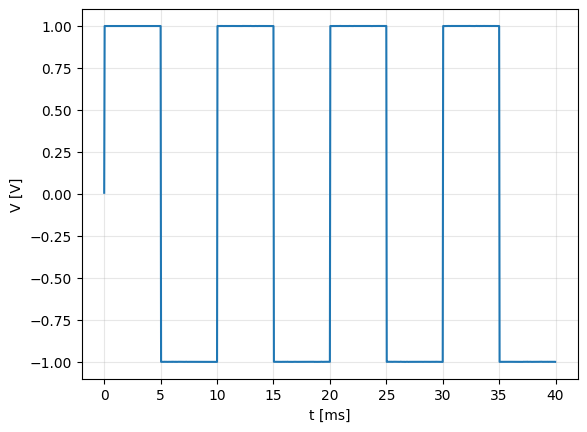

In [26]:
y = ai0.trace()
t = daq.ai.time_axis()

start, end = 0, 1000

plt.plot(t[start:end]*1e3, y[start:end])
plt.xlabel("t [ms]")
plt.ylabel("V [V]")
plt.grid(alpha=0.3)

---
# 2. Clock check — the board against the rubidium

The board's clock does not know it is wrong. It divides its 20 MHz timebase,
reports a rate confidently, and drifts seconds per day. The FS725 emits one
pulse per **atomic** second.

### Why the counter is wired backwards

| | |
|---|---|
| what is **counted** | `ai/SampleClock` — the board's own sample clock |
| what **latches** it | the 1 pps, used as the counter task's *sample clock* |

Each value returned is therefore *the scan index that was current when an
atomic second arrived* — the edge table, in the same units as the data.

Feeding the 1 pps into an analog channel instead would miss ~75 % of the pulses
at 25 kS/s: the ADC samples instantaneously and the pulse is 10 µs wide.

### How long to run it

Each edge resolves to ±1 scan (40 µs), and the estimate spans the measurement:

| `seconds=` | resolution | equivalent |
|---|---|---|
| 10 | ~6 ppm | ±0.5 s/day |
| 60 | ~1 ppm | ±0.09 s/day |
| 600 | ~0.1 ppm | ±0.01 s/day |

10 s confirms the wiring. 600 s once gives the number you would quote.

**Reading the output:** edges caught ≈ `seconds`; *discarded* values are normal
(every acquisition ends with one latched value that is not an atomic second);
ppm in the tens is normal — the board is specified to ±50 ppm, and what matters
is that it is **stable**, because that is what makes it correctable.

## Clock check

In [ ]:
ao0, ao1 = daq.ao.setup({"ao0": {"wave": 1.0},
                         "ao1": {"dc": 0.0}},        # the trigger line, idle LOW
                        shape="square", freq=100)
ai0, = daq.ai.setup({"ai0": (-2.0, 2.0)}, rate=25_000, duration=5,
                    trigger="/Dev1/PFI8")

daq.pps.terminal("/Dev1/PFI9")
daq.pps.counter("ctr1")

daq.ai.set_on_armed(pulse)     # ao1 -> PFI 8, fired when armed

daq.wiring()

In [10]:
daq.clock_check(seconds=10)

1 pps edges caught: 11 (expected ~10)
  1 latched value(s) discarded - not whole atomic seconds (normally the end-of-acquisition one)

  edge   scan index   scans since previous
     0            0             
     1       25,000       25,000
     2       50,000       25,000
     3       74,999       24,999
     4       99,999       25,000
     5      124,999       25,000
     6      149,998       24,999
     7      174,998       25,000
     8      199,998       25,000
     9      224,997       24,999
    10      249,997       25,000

  nominal rate             25,000.000 S/s
  true rate vs rubidium    24,999.700 scans/atomic second
  board clock error             +12.0 ppm (slow)

  square on ai0: 999 periods, 250.000 samples each
  its real frequency is 99.9988 Hz

  over a day that error is 1.04 s


{'counts': array([     0,  25000,  50000,  74999,  99999, 124999, 149998, 174998,
        199998, 224997, 249997], dtype=int64),
 'n_edges': 11,
 'n_edges_expected': 10,
 'nominal_rate': 25000.0,
 'true_rate': 24999.7,
 'ppm': 12.000144001698917,
 'n_dropped': 1,
 'square_channel': 'ai0',
 'samples_per_period': 250.0,
 'true_freq': 99.9988,
 'n_periods': 999}

---
# 3. The atomic time axis

`daq.acquire_with_pps()` returns `(data, edges)` — one record on every enabled
channel plus the atomic seconds inside it, as **scan indices**. An event at
scan *k* and an atomic second at scan *e* are on the same ruler: no clock
conversion, no assumption about the rate.

It lives on the instrument because it drives two subsystems: the counter must
start **before** the AI clock, and be stopped and joined before its queue is
drained.

| | |
|---|---|
| `daq.ai.time_axis()` | scan ÷ actual rate — the **board's** clock |
| `daq.ai.atom_time_axis()` | interpolated between 1 pps edges — the **rubidium** |

The second never uses the sample rate. It asks *where does this sample sit
between two atomic ticks?* — which is what absorbs the drift.

## Inject and read waveform triggered and clocked

In [ ]:
ao0, ao1 = daq.ao.setup({"ao0": {"wave": 1.0},
                         "ao1": {"dc": 0.0}},        # the trigger line, idle LOW
                        shape="square", freq=100)
ai0, = daq.ai.setup({"ai0": (-2.0, 2.0)}, rate=25_000, duration=60*5,
                    trigger="/Dev1/PFI8")

daq.pps.terminal("/Dev1/PFI9")
daq.pps.counter("ctr1")

daq.ai.set_on_armed(pulse)     # ao1 -> PFI 8, fired when armed

In [ ]:
# generate the output signal; set_on_armed fires the trigger for us
with daq.ao.generating():      # this context manager starts and stops the generator
    data, edges = daq.acquire_with_pps()

ao1.dc(0.0)                    # trigger line back low

In [13]:
t_board = daq.ai.time_axis()
t_atomic = daq.ai.atom_time_axis()
y = data["ai0"]

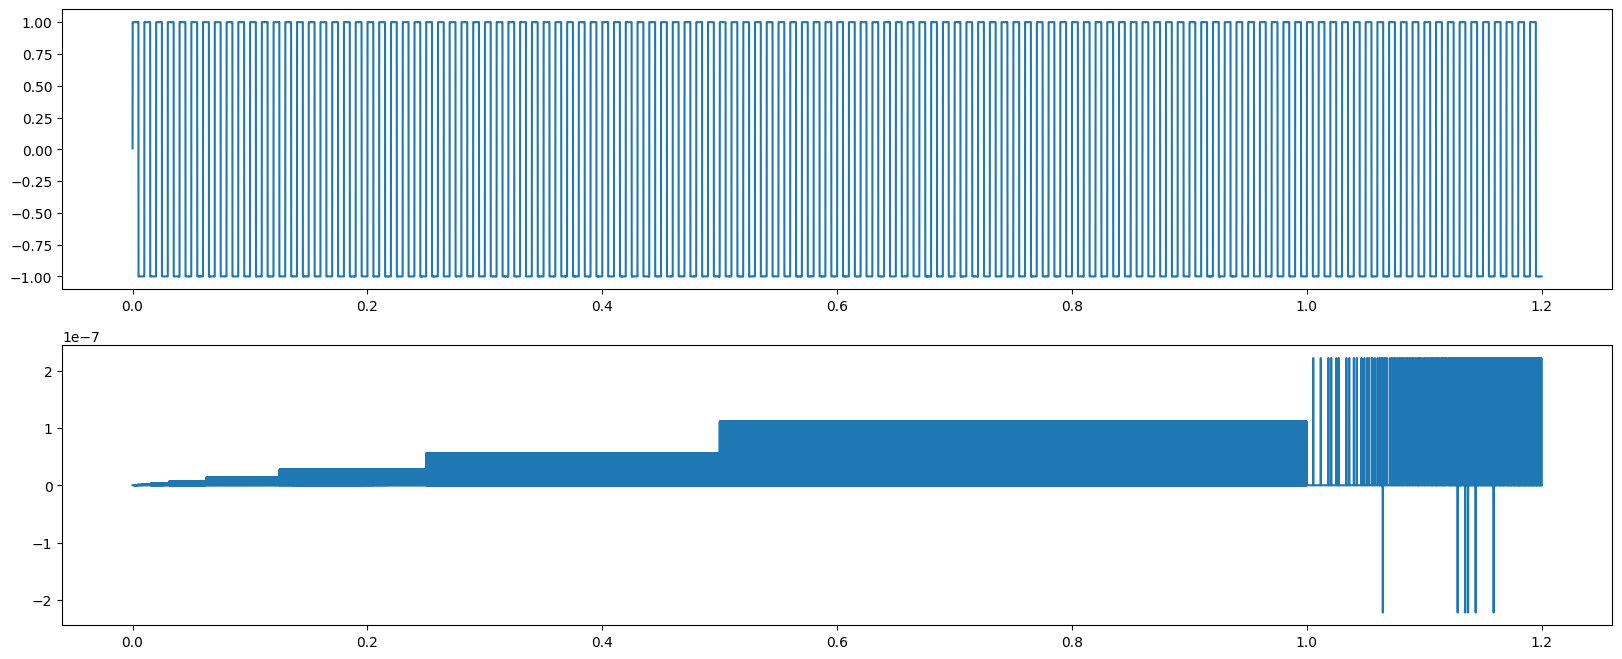

In [16]:
start, end = 0, 30000
fig, ax = plt.subplots(2, 1, figsize=(20,8))
ax[0].plot(t_atomic[start:end], y[start:end])


res = t_atomic[start:end] - t_board[start:end]

ax[1].plot(t_atomic[start:end], res*1e9)

### The drift plot

`t_atomic - t_board` is the board's clock walking away from the rubidium. The
slope is the error in ppm. The **staircase is real**, not noise: each edge is
quantised to one scan (40 µs) and the correction is linear between edges, so
each step lasts one second.

Plotting every edge makes the axis solid black — `edges[::10]` is enough to see
where the seconds are.

Text(0, 0.5, '$\\Delta t$ [$\\mu$s]')

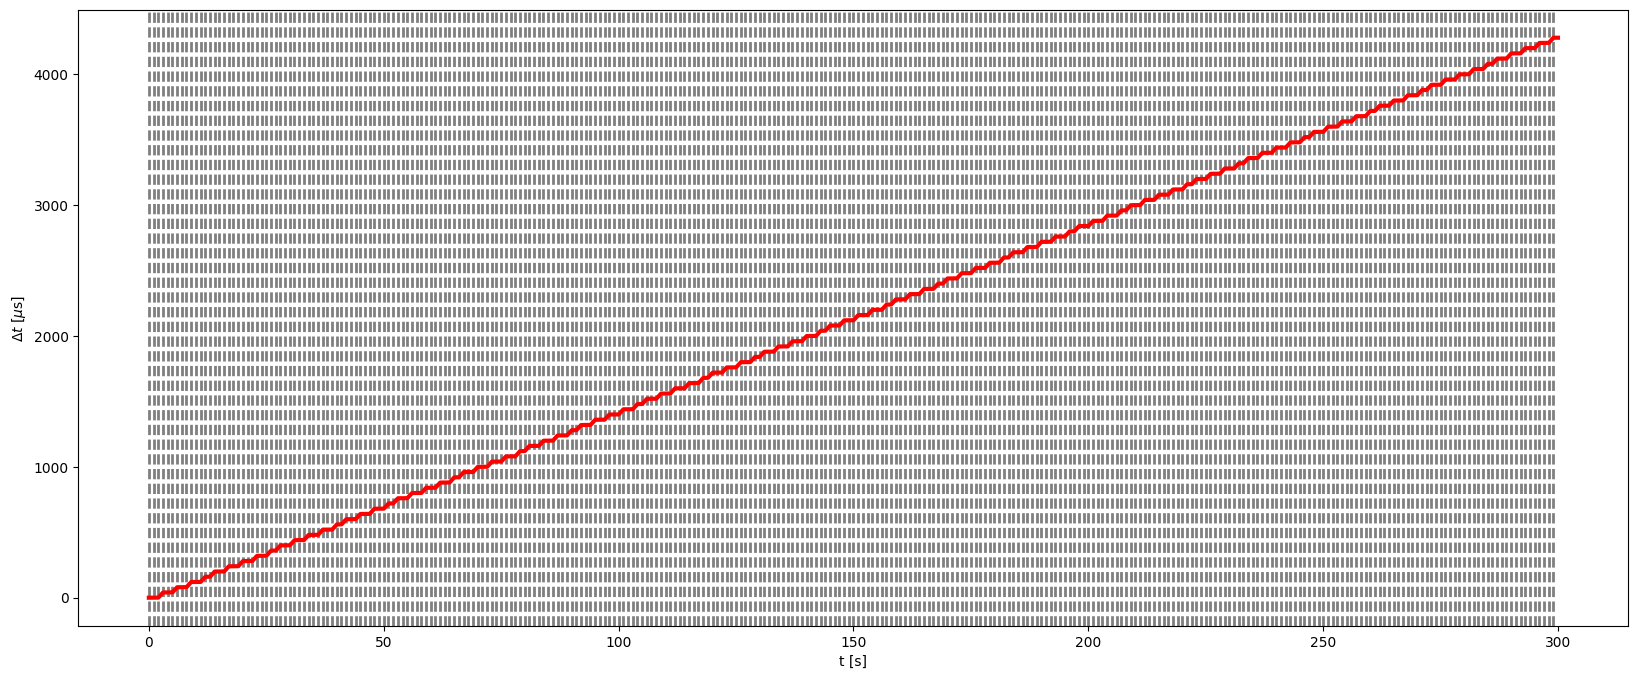

In [17]:
start, end = 0, len(t_atomic) -1000
fig, ax = plt.subplots(1, 1, figsize=(20,8))

# plot vertical lines
for edge in edges:
    if edge > end:
        break
    ax.axvline(t_atomic[edge], color="black", alpha=0.5, lw=2, linestyle="--")

res = t_atomic[start:end] - t_board[start:end]

ax.plot(t_atomic[start:end], res*1e6,  color="red", lw=3)

ax.set_xlabel("t [s]")
ax.set_ylabel(r"$\Delta t$ [$\mu$s]")

---
# 4. Long run — recording to disk

### `daq.long_run(outdir, ...)`

| argument | meaning |
|---|---|
| `outdir` | a **new** directory. Reusing one is refused: two runs in a directory cannot be told apart afterwards |
| `hours` | how long; `None` runs until stopped |
| `rotate_minutes` | `None` = one file per channel for the whole run; `60` = a new file each hour |
| `background` | `True` returns a handle at once and records in a thread |
| `require_pps` | `False` allows a run with no rubidium (bench testing) |
| `live_decimate`, `live_seconds` | size the in-RAM preview buffer — they **do not affect what is recorded** |
| `to_hdf5` | also convert closed segments to `.h5` in the background |

**Rotation** changes nothing about the data — scan indices stay global and
continuous. It exists so a *closed* file can be compressed, converted or rsynced
while the run continues, and so a disk problem costs one segment instead of
everything.

### What lands on disk

```
outdir/
    run.json        the instrument settings at the start
    manifest.jsonl  which file holds which scans — one JSON per line
    edges.i64       every 1 pps edge of the whole run, as scan indices
    markers.i64     every marker, same units — absent if you sent none
    seg_00000_ai0_20260813T101500Z.f32     the samples: raw float32, no header
```

Nothing is filtered before writing. **A recording you cannot re-take must not be
stored already interpreted** — when the interpretation turns out to be wrong,
the raw file is what lets you fix it tomorrow instead of measuring again.

## Long run

In [ ]:
ao0, ao1 = daq.ao.setup({"ao0": {"wave": 1.0},
                         "ao1": {"dc": 0.0}},        # the trigger line, idle LOW
                        shape="square", freq=100)
ai0, = daq.ai.setup({"ai0": (-2.0, 2.0)}, rate=25_000, trigger="/Dev1/PFI8")

daq.pps.terminal("/Dev1/PFI9")
daq.pps.counter("ctr1")

daq.ai.set_on_armed(pulse)     # ao1 -> PFI 8, fired when the run arms

daq.ao.start()

outdir = "test_longrun_2"

print(daq.ai.actual_rate(), "S/s actual")

### Check twice before committing hours

`onboard` must be **True**, and `daq.wiring()` is worth a last look before you
walk away.

In [36]:
daq.check(strict=True)             # raises if anything cannot run
print("AO regenerates onboard:", daq.ao.onboard(),
      f"(buffer {daq.ao.buffer_len():,} of {daq.ao.fifo_samples():,} samples)")
daq.wiring()

daq: 0 error(s), 1 warning(s)
  warning [daq] ai.trigger and pps.terminal are the same line, so scan 0 IS an
                atomic second and the first edge comes back as 0. Deliberate and
                useful - flagged only so it is not a surprise.
AO regenerates onboard: True (buffer 1,000 of 8,191 samples)
daq: Dev1
  role        channel  connection  terminal  signal  note
  ----------  -------  ----------  --------  ------  -----------------------------
  ai          ai0      signal (+)         1  AI 0    -2..+2 V RSE
  ai          ai0      return             3  AI GND
  1 pps       PFI8     signal            81  PFI8    latches scans on counter ctr1
  1 pps       PFI8     return            82  D GND
  ao wave     ao0      signal            15  AO 0    square 100 Hz, 1 V  [running]
  ao wave     ao0      return            16  AO GND
  ai trigger  PFI8     signal            81  PFI8    /Dev1/PFI8
  ai trigger  PFI8     return            82  D GND
  ao trigger  PFI8     signal    

[{'role': 'ai',
  'channel': 'ai0',
  'connection': 'signal (+)',
  'terminal': 1,
  'signal': 'AI 0',
  'note': '-2..+2 V RSE'},
 {'role': 'ai',
  'channel': 'ai0',
  'connection': 'return',
  'terminal': 3,
  'signal': 'AI GND',
  'note': ''},
 {'role': '1 pps',
  'channel': 'PFI8',
  'connection': 'signal',
  'terminal': 81,
  'signal': 'PFI8',
  'note': 'latches scans on counter ctr1'},
 {'role': '1 pps',
  'channel': 'PFI8',
  'connection': 'return',
  'terminal': 82,
  'signal': 'D GND',
  'note': ''},
 {'role': 'ao wave',
  'channel': 'ao0',
  'connection': 'signal',
  'terminal': 15,
  'signal': 'AO 0',
  'note': 'square 100 Hz, 1 V  [running]'},
 {'role': 'ao wave',
  'channel': 'ao0',
  'connection': 'return',
  'terminal': 16,
  'signal': 'AO GND',
  'note': ''},
 {'role': 'ai trigger',
  'channel': 'PFI8',
  'connection': 'signal',
  'terminal': 81,
  'signal': 'PFI8',
  'note': '/Dev1/PFI8'},
 {'role': 'ai trigger',
  'channel': 'PFI8',
  'connection': 'return',
  'termina

### Rehearse for 3 seconds

A wiring mistake found here costs three seconds instead of a night.

`edge_report(edges, nominal_rate)` says whether the timing is sound: how many
latched values were discarded and why, how many atomic seconds were **missed**
(kept as gaps — the numbering accounts for them), and the drift measured across
the whole record.

75,000 samples, -1.001 .. +1.001 V
1 pps: 4 usable of 4 latched values
  spans 3 atomic seconds
  true rate 24,999.667 scans/atomic s
  clock error +13.33 ppm -> 1.15 s/day


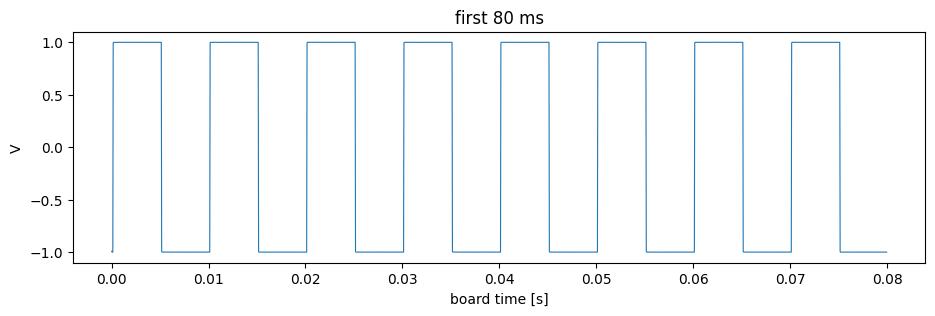

In [5]:
daq.ai.duration(3.0)
data, edges = daq.acquire_with_pps()
y = data["ai0"]

print(f"{len(y):,} samples, {y.min():+.3f} .. {y.max():+.3f} V")
edge_report(edges, nominal_rate=daq.ai.actual_rate())

t = daq.ai.time_axis()
plt.figure(figsize=(11, 3))
plt.plot(t[:2000], y[:2000], lw=0.8)
plt.xlabel("board time [s]"); plt.ylabel("V"); plt.title("first 80 ms")
plt.show()

### Start

AO first, so it is armed before the input task starts. `background=True`
returns immediately — the cells below run while it records.

**Put `OUTDIR` on a local disk.** A sync client uploading a continuously growing
file stalls the write, and a stalled write becomes a buffer overflow.

In [37]:
daq.ao.start()                     # arms; fires on the next PFI8 edge

OUTDIR = "long_run_test_2"

run = daq.long_run(OUTDIR,
                   hours=0.1,
                   rotate_minutes=2,
                   background=True)
run

<LongRun running long_run_test_2>

long run -> long_run_test_2
  25,000.000 S/s x 1 channel(s) ['ai0'], float32, rotating every 2 min
  8.6 GB/day, 60 GB/week
  interrupt to stop cleanly



  stopped at 86.0 s
  [00000] 2,150,000 scans x 1 ch  9 MB

done: 2,150,000 scans (0.02 h) on 1 channel(s), 87 pps edges


## 5.1 Watching it — two different things

| | `daq.live_preview()` | the files (`LiveScope`, `RunFiles`) |
|---|---|---|
| where | a deque in RAM | disk |
| how much | last `live_seconds` (60) | **everything** |
| channels | the first one only | all of them |
| resolution | min/max per `live_decimate` block | every sample |
| answers | *"is it alive?"* | *"what did it measure?"* |

**What the preview actually holds.** Every 0.2 s a chunk of 5,000 samples
arrives. All 5,000 go to disk. The preview additionally stores, for each block
of `live_decimate`=100 samples, its **min and its max** — 100 numbers instead
of 5,000 — and the deque keeps 300 such entries (60 s) and drops the oldest.

It stores min/max rather than every 100th sample because striding is
undersampling: at an effective 250 S/s a 100 Hz square has 2.5 samples per
period and renders as ragged nonsense with the wrong duty cycle, while the file
is perfect. **That was the bug in the earlier notebook** — the data was never
wrong, the summary was. Min/max cannot misrepresent the envelope, but the
*order within a block* is not real, so for the true waveform use §5.3.

15 s  segment 0  alive=True


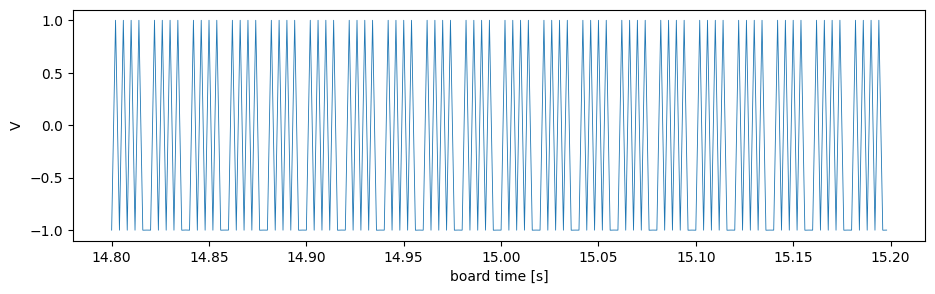

In [39]:
window = 200

s = run.status()
t, y = daq.live_preview()
print(f"{s['seconds']:,.0f} s  segment {s['segment']}  alive={run.alive}")



if len(y):
    plt.figure(figsize=(11, 3))
    plt.plot(t[-window:], y[-window:], lw=0.6)
    plt.xlabel("board time [s]"); plt.ylabel("V"); plt.show()

## 5.2 Live plot

Two things must happen every frame, and missing either is why a live plot looks
broken:

1. **clear the axes** — `ax.plot()` in a loop *adds* a line each time, so after
   a few hundred frames the figure is hundreds of lines and grinds to a halt;
2. **push the figure to the screen** — with the default `%matplotlib inline`
   there is no GUI event loop, so `plt.pause()` redraws nothing and the cell
   just blocks. The figure must be re-`display`ed with the previous output
   cleared.

`time.sleep()` alone never works on inline: it sleeps without redrawing. The
cell below does both — that is why it works.

Finish continuous plotting


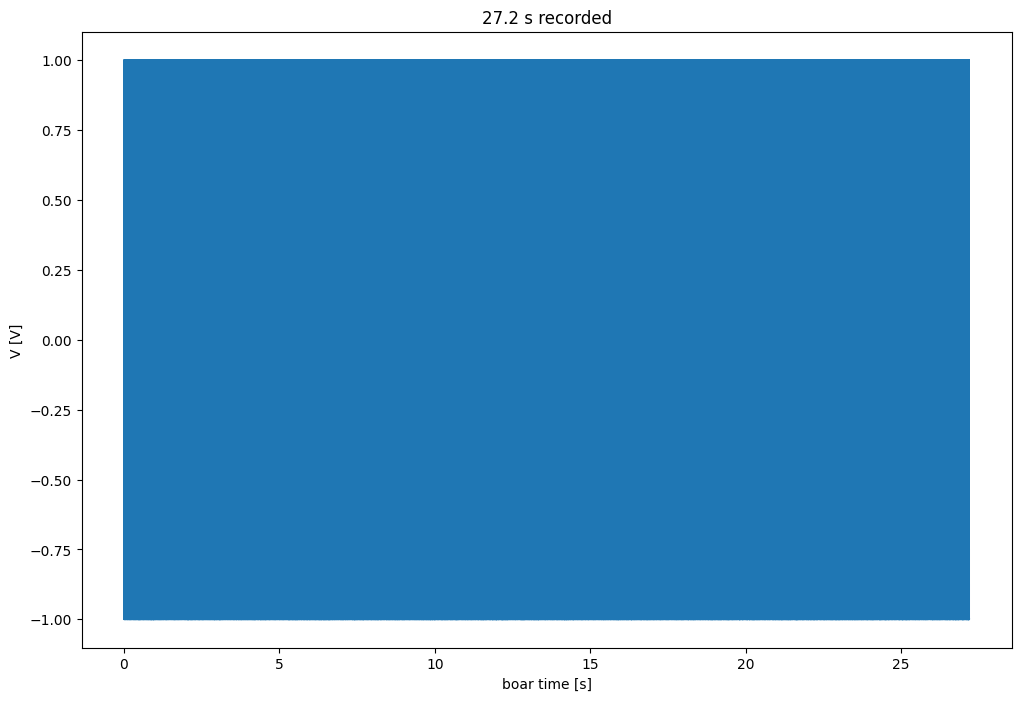

In [40]:
from IPython.display import display, clear_output

fig, ax = plt.subplots(figsize=(12,8))

try:
    while run.alive:
        t, y = daq.live_preview()
        ax.clear()

        if len(y):
            ax.plot(t, y, lw=1)
            ax.set_xlabel("boar time [s]"); ax.set_ylabel("V [V]")
            seconds = run.status()["seconds"]
            ax.set_title(f"{seconds} s recorded")
            #ax.set_title(f"{run.status()["seconds"]:.0f} s")

        clear_output(wait=True)
        display(fig)
        #time.sleep(0.05)

except KeyboardInterrupt:
    print("Finish continuous plotting")
    pass

**Better, if you install `ipympl`** (`pip install ipympl`): put
`%matplotlib widget` in its own cell above and re-run from there. Real pan and
zoom, no flicker, and updating one line's data is much cheaper than redrawing.

In [ ]:
# needs %matplotlib widget
fig, ax = plt.subplots(figsize=(12, 4))
line, = ax.plot([], [], lw=1)
ax.set_xlabel("board time [s]"); ax.set_ylabel("V [V]"); ax.grid(alpha=0.3)

try:
    while run.alive:
        t, y = daq.live_preview()
        if len(y):
            line.set_data(t, y)          # update the SAME line - no pile-up
            ax.relim(); ax.autoscale_view()
        plt.pause(0.5)                   # redraws AND sleeps
except KeyboardInterrupt:
    pass

## 5.3 An oscilloscope view

What makes a scope readable is not the drawing — it is the **trigger**. Without
it the waveform slides across the screen every frame; with it, it stands still.

This reads **real samples from the file**, not the preview buffer, because the
buffer is an envelope whose intra-block order is not real.

* `RunFiles(outdir, channel)` — the run's files as they grow. It re-reads the
  manifest and file sizes on demand (a cached size is a lie 200 ms later) and
  finds the **open** segment by name, since that one has no manifest entry
  until it closes.
* `files.n_scans()` — how much has been written so far.
* `files.read(start_scan, n)` — just that window: one seek, one read, across
  segment joins. A 10 s window of a week-long run touches about a megabyte.

`hits[hits >= pre]` matters: without it, a frame whose first crossing lands
before `pre` cannot be shifted back and the trace jitters.

In [ ]:
files = RunFiles(OUTDIR, "ai0")
rate = files.rate

SPAN, PRE = 1500, 100        # samples on screen, samples shown before the trigger

def trigger(y, level=0.0, pre=PRE, n=SPAN):
    """Align on the first rising crossing - a scope trigger, four lines."""
    above = y >= level
    hits = np.flatnonzero(~above[:-1] & above[1:]) + 1
    hits = hits[hits >= pre]                 # need room to show the run-up
    if len(hits) == 0:
        return y[:n]                         # free-run if nothing crosses
    return y[hits[0] - pre : hits[0] - pre + n]

fig, ax = plt.subplots(figsize=(12, 4))
line, = ax.plot([], [], lw=1)
ax.set_xlabel("ms"); ax.set_ylabel("V"); ax.grid(alpha=0.3)

try:
    while run.alive:
        total = files.n_scans()
        y_win = files.read(max(0, total - 5000), 5000)      # the last 0.2 s
        if len(y_win) < SPAN:
            time.sleep(0.2); continue
        y_win = trigger(y_win)
        line.set_data(np.arange(len(y_win)) / rate * 1e3, y_win)
        ax.set_xlim(0, len(y_win) / rate * 1e3)
        ax.set_ylim(y_win.min() - 0.1, y_win.max() + 0.1)
        ax.set_title(f"{total / rate:,.0f} s recorded")
        clear_output(wait=True); display(fig)
        time.sleep(0.2)
except KeyboardInterrupt:
    print("stopped")

## 5.4 `LiveScope` — navigate the whole run while it records

```python
scope = LiveScope(outdir, channel="ai0", width=5.0)
scope.show()          # follows the end of the file; interrupt to stop
scope.goto(120.0)     # jump to t = 120 s, stop following
scope.zoom(0.1)       # 10x narrower
scope.pan(-1)         # one window back
scope.follow()        # back to live
scope.step()          # draw ONE frame, for your own loop
```

It draws **min/max per pixel column** — what a digital scope does, for the same
reason. A 300 s window is 7.5 M samples against ~1500 pixels; taking every
5000th sample drops a 200 µs spike about 999 times in 1000. Measured on a run
with fifteen 200 µs spikes: min/max keeps **15 of 15**, striding keeps **0**.
Zoom in past one sample per column and it stops decimating entirely.

Nothing in `livescope` touches the DAQ, so a slow plot cannot stall the
acquisition. It can run in another process, or from a laptop over a share.

In [ ]:
scope = LiveScope(OUTDIR, channel="ai0", width=0.05)   # 50 ms: no decimation
scope.show()          # interrupt the kernel to stop

In [72]:
run.stop()

True

---
# 5. Markers — recording *when* things happened

The 1 pps gives you a **ruler**: every edge is one atomic second, and you know
the scan index of each. What it does not tell you is where the interesting
moments are — when the OPX started a run, stopped one, or paused to drain its
buffer.

`daq.marker` is the other half. It is the **same counter trick** as the 1 pps,
on the free counter, pointed at a different wire:

| wire | counter | what you get |
|---|---|---|
| rubidium 1 pps | `ctr1` (`daq.pps`) | atomic seconds — the ruler |
| OPX marker line | `ctr0` (`daq.marker`) | events — when things happened |

Both record **scan indices**, and that is the whole point: markers, 1 pps
edges, samples and segment boundaries are all the same kind of number. Relating
an event to the data is `y[mark]`; relating it to the rubidium is one call.
Nothing is converted, so nothing can be converted wrong.

**Why the scan index and not a time.** A time would have to be derived by
dividing by a rate that is itself wrong by ~12 ppm, and frozen into the file at
whatever the driver's clock correction happened to be that day. A scan index is
what the hardware measures, it is an exact integer, it indexes the data
directly, and it can be **re-timed** when the correction improves — which it
has, twice.

**One line, one kind of pulse.** Only one counter is free, so the hardware
cannot tell "start" from "stop". Let **order** carry the meaning: your OPX
program defines the sequence, so mark 0 is whatever it emits first. The DAQ
only has to say *when*.

**What it buys.** The DAQ records continuously; the OPX does not. The markers
say which stretches of an unbroken recording correspond to the OPX doing
something — and which are the gaps while it reset or drained. The DAQ becomes
a witness for an instrument that stops, because it never does.

## 5.1 A bench trial — the board triggers and marks itself

Before wiring the OPX, simulate it: drive **one** analog output as a digital
line, doing exactly what the OPX will do — one pulse to start the run, then a
few more to mark what happens during it.

This exercises three things that have never run together: **markers**, **two AI
channels at once**, and **a trigger arriving while the counter is already
waiting**.

### Three signals, three PFI lines — but only **two** counters

That is not a shortage, because the three do different jobs:

| signal | what it needs | counter |
|---|---|---|
| **1 pps** → `daq.pps` | a counter to **timestamp** each pulse | `ctr1` |
| **markers** → `daq.marker` | a counter to **timestamp** each pulse | `ctr0` |
| **trigger** → `ai.trigger` | the timing engine's start-trigger input | **none** |

A start trigger is not recorded — it **defines scan 0**. There is nothing to
timestamp, because the answer is always zero. So two counters is exactly
enough, and both are spoken for.

### One line does both — the trigger IS the first marker

A PFI input fans out inside the board, so **one wire** can feed the start
trigger *and* a counter at the same time:

```python
daq.ai.setup(..., trigger="/Dev1/PFI8")
daq.marker.terminal("/Dev1/PFI8")        # the SAME line
```

Then the pulse that starts the acquisition is also its first marker, and it
lands at **scan 0** — which is where the trigger is by definition. So the
leading `0` in `markers.i64` is not an artefact, it is the answer:

```
marks[0] == 0        the trigger
marks[1:]            whatever the OPX did next, on the same line
```

One cable, one PFI line, and the trigger arrives already timestamped on the
same ruler as everything else. `daq.check()` prints a **note** when it sees
this arrangement, so nobody later mistakes that zero for rubbish.

### Wiring

`ao0` and `ai0` are left alone for the loopback used earlier:

| from | pin | to | pin | why |
|---|---|---|---|---|
| **AO 1** | 31 | **PFI 8** | 81 | trigger **and** markers |
| **AO 1** | 31 | **AI 1** | 4 | …and AI 1 watches the same pulses |
| rubidium 1 pps | — | **PFI 9** | 83 | the ruler |

Returns: AO GND **32**, AI GND **3**, D GND **82**.

Wiring that output to a PFI line **and** an AI channel is what makes this a
test rather than a demonstration: the counter records a *scan index*, AI 1
records the *pulse*. If the two agree, the whole chain is verified.

### ⚠ Launch the pulse source from `set_on_armed`

The one thing this arrangement demands. A pulse sent **before the task has
armed** triggers nothing — the task is not listening yet — and still latches a
`0` into the marker table, so you would get a mark with no acquisition behind
it. `daq.ai.set_on_armed(callback)` fires in the only moment when the board is
armed and nothing has been asked to fire yet, which is exactly this window. In
the trial below the `time.sleep(3)` stands in for it.

### ⚠ Never drive a PFI input negative

PFI lines are **TTL inputs**, absolute maximum about **−0.5 V to +5.5 V**. The
±1 V square used earlier in this notebook would put −1 V on the pin, which is
outside that. For this trial the outputs only ever sit at **0 V or 5 V**.

### Why DC levels and not a waveform

Setting a DC level while a waveform is running rebuilds the AO task, which
would restart and glitch the waveform. In **pure DC mode** — no channel with
role `"wave"` — each `dc()` is an independent untimed write with nothing to
restart, so you can pulse a line from Python whenever you like. That is also
much closer to what the OPX will actually do.

In [ ]:
# two INPUTS: ai1 watches the trigger/marker line, ai2 is a spare so that
# multichannel gets exercised too. 0..5 V signals, so give them room -
# DAQmx snaps up to the nearest hardware range.
ai1, ai2 = daq.ai.setup({"ai1": (-1.0, 6.0),    # watches the trigger/marker line
                         "ai2": (-1.0, 6.0)},   # spare, exercises multichannel
                        rate=25_000, trigger="/Dev1/PFI8")

# ONE output line: it triggers the acquisition, and every pulse on it is a
# marker. Pure DC mode - no channel has role "wave" - so each dc() is an
# untimed write with nothing to restart.
ao1, = daq.ao.setup(channels_role={"ao1": {"dc": 0.0}})   # idle low

daq.pps.terminal("/Dev1/PFI9")       # the ruler
daq.marker.terminal("/Dev1/PFI8")    # the SAME line as the trigger
daq.pps.counter("ctr1"); daq.marker.counter("ctr0")

daq.check(strict=True)
daq.terminal_roles()

In [ ]:
daq.wiring()

# and the two channels are not sampled at the same instant - one ADC, one mux
for ch in daq.ai.active:
    print(f"{ch.short_name}: sampled {ch.time_offset()*1e6:5.2f} us into each scan")

### Run it

The order matters and mirrors the real thing:

1. both lines **low**, so the first edge is a clean rising one
2. `long_run` starts — the counter begins immediately, but the **AI task waits**
   for PFI 8, so every 1 pps edge during the wait latches 0 and is discarded
3. we pulse AO 1 → that is the **trigger**, so scan 0 is that instant, **and**
   it is marker 0
4. we pulse AO 1 again a few times → those are markers 1–4

In [ ]:
import time

OUTDIR = Path("marker_trial")          # a NEW directory

ao1.dc(0.0)                            # idle low
time.sleep(0.2)

run = daq.long_run(OUTDIR, hours=40/3600,      # 40 seconds
                   background=True, verbose=False)
time.sleep(3)                           # let the AI task arm and WAIT
print("armed; the counter is running but the AI clock is not")

ao1.dc(5.0); time.sleep(0.02); ao1.dc(0.0)     # <-- TRIGGER *and* marker 0
print("triggered - scan 0 is now, and it is also the first marker")

for i in range(1, 5):                   # four MORE markers, 6 s apart
    time.sleep(6)
    ao1.dc(5.0); time.sleep(0.02); ao1.dc(0.0)     # a 20 ms pulse
    print(f"   marker {i} sent")

run.join()
ao1.dc(0.0)
print("done")

### Read it back — and check the markers against the signal

`marker_times` gives the scan index and atomic second of every marker. AI 1
recorded the same pulses as a waveform, so finding its rising edges gives an
**independent** answer. They should agree to about one scan (40 µs).

One asymmetry to expect: the counter sees marker 0 (the trigger) at scan 0,
but AI 1 cannot — the clock starts *on* that edge, so the ADC catches the
pulse's tail rather than its start. Compare `marks[1:]` against the edges
after the first.

In [ ]:
manifest, edges = load_long_run(OUTDIR)
rate = manifest[0]["nominal_rate"]

print("=== timing ===")
edge_report(edges, nominal_rate=rate)
info = trigger_time(OUTDIR)
print(f"\ntrigger fired {info['first_edge_seconds']:.4f} s before the first "
      f"atomic second")

print("\n=== markers ===")
marks, t_marks = marker_times(OUTDIR)
for i, (m, t) in enumerate(zip(marks, t_marks)):
    print(f"   marker {i}: scan {m:>9,}   atomic {t:+9.4f} s")
print(f"\n   marks[0] = {marks[0]} -> the TRIGGER, at scan 0 by definition")
print(f"   spacing of the rest: {np.diff(t_marks)[1:].round(3)} s   (6 s apart)")

In [ ]:
# INDEPENDENT CHECK: ai1 watched the marker line, so find its rising edges
idx, y = load_run(OUTDIR, "ai1")
above = y >= 2.5
seen = np.flatnonzero(~above[:-1] & above[1:]) + 1 + idx[0]   # global scans

print(f"counter recorded : {marks.tolist()}")
print(f"seen in ai1      : {seen.tolist()}")

if len(seen) == len(marks):
    delta = marks - seen
    print(f"difference       : {delta.tolist()} scans "
          f"= {(delta / rate * 1e6).round(1).tolist()} us")
    print("\nAgreement within a scan or two means the whole chain is right:")
    print("  the counter latched the same instant the ADC saw the edge.")
else:
    print(f"\nMISMATCH: {len(marks)} marks vs {len(seen)} edges in the data.")
    print("  more edges than marks -> the pulse bounced, or ai1 sees noise")
    print("  fewer -> the pulse missed the PFI threshold; check the wiring")

In [ ]:
# and the picture: the marker pulses with their recorded positions on top
t_atomic = times_from_edges(idx, edges, scans_per_second=rate)

fig, ax = plt.subplots(figsize=(13, 4))
step = max(1, len(y) // 200_000)
ax.plot(t_atomic[::step], y[::step], lw=0.8, label="ai1 (marker line)")
for i, t in enumerate(t_marks):
    ax.axvline(t, color="red", ls="--", lw=1.5,
               label="counter marks" if i == 0 else None)
ax.set_xlabel("atomic time [s]"); ax.set_ylabel("V"); ax.legend()
ax.grid(alpha=0.3)
ax.set_title("red lines = what the counter recorded, trace = what the ADC saw")

### What each outcome tells you

| result | meaning |
|---|---|
| marks and edges agree within a scan or two | the whole chain works — wire the OPX in |
| more edges than marks | the pulse bounced, or AI 1 is picking up noise: raise the 2.5 V threshold |
| fewer edges than marks | the pulse did not reach the PFI threshold — check the D GND return |
| no marks at all | `daq.marker.terminal` unset, or the counter never claimed — `daq.terminal_roles()` |
| `t_marks` starts negative | normal: the markers came before the first atomic second |

Once this passes, replacing AO 1 with the OPX's own output changes **nothing**
in the analysis — same scan indices, same edge table, same two lines of
read-back. The only thing that changes is *what* is emitting the pulse.

And in the real setup, launch the QM job from `daq.ai.set_on_armed(...)`
rather than a `time.sleep`: a pulse sent before the task arms triggers
nothing and still leaves a stray 0 in the marker table.

## 5.2 A longer trial — 10 minutes, random markers

The bench trial above sends markers on a metronome, which proves the wiring
but not much else. This one is closer to a real run: **10 minutes**, the
trigger arriving whenever the acquisition happens to be ready, and markers at
**random** intervals — as the OPX would emit them when a measurement finishes
or a buffer fills.

Two things are done properly here that the first trial faked.

**The trigger is sent from `set_on_armed`.** Earlier it was a `time.sleep(3)`
and a hope. `daq.ai.set_on_armed(callback)` fires in the *only* moment when
the board is armed and nothing has been asked to fire yet — so the pulse
cannot arrive too early. This is exactly where `qm.execute(prog)` goes in the
real experiment, and the reason the hook exists.

**`hours` is counted from the trigger.** The length is in *scans*, and with a
trigger set the sample clock does not tick until the edge arrives, so nothing
accumulates while the task waits:

| trigger arrives | recorded | wall clock |
|---|---|---|
| immediately | 10 min | 10 min |
| 2 min late | **10 min** | 12 min |

You always get the full ten minutes of data. Only the wall clock runs longer.
(And if the trigger never comes, nothing is recorded at all — the read times
out after 60 s, that counts as an error, and with `restart=True` the run keeps
retrying. `run.status()['seconds']` stuck at 0 is what that looks like.)

In [ ]:
import random

OUTDIR = Path("marker_trial_10min")        # a NEW directory

ai1, ai2 = daq.ai.setup({"ai1": (-1.0, 6.0),    # watches the trigger/marker line
                         "ai2": (-1.0, 6.0)},
                        rate=25_000, trigger="/Dev1/PFI8")
ao1, = daq.ao.setup(channels_role={"ao1": {"dc": 0.0}})    # idle LOW

daq.pps.terminal("/Dev1/PFI9")        # the ruler
daq.marker.terminal("/Dev1/PFI8")     # the SAME line as the trigger
daq.pps.counter("ctr1"); daq.marker.counter("ctr0")

def pulse(width=0.02):
    """A 20 ms TTL pulse on the trigger/marker line."""
    ao1.dc(5.0); time.sleep(width); ao1.dc(0.0)

# THE TRIGGER, fired the instant the task is armed - no sleep, no race.
# In the real experiment this line becomes qm.execute(prog).
daq.ai.set_on_armed(pulse)

daq.check(strict=True)      # expect ONE note: marker and trigger share a line

In [ ]:
sent_at = []                               # wall time of each marker WE sent

run = daq.long_run(OUTDIR, hours=10/60, background=True, verbose=False)
print("armed - the trigger will fire from set_on_armed")

t_start = time.time()
while run.alive and time.time() - t_start < 9 * 60:
    time.sleep(random.uniform(20, 120))     # random, like a real experiment
    if not run.alive:
        break
    pulse()
    sent_at.append(time.time())
    print(f"   marker {len(sent_at)} sent at {time.time()-t_start:6.1f} s")

run.join()
ao1.dc(0.0)
print(f"done - {len(sent_at)} markers sent after the trigger")

### Read it back

`marks[0]` is the trigger, at scan 0. Everything after it is a marker you sent.
`marker_times` puts them all on the atomic ruler in one call — the same edge
table that times the samples, so a marker and the data around it cannot
disagree.

In [ ]:
manifest, edges = load_long_run(OUTDIR)
rate = manifest[0]["nominal_rate"]

print("=== the ruler ===")
report = edge_report(edges, nominal_rate=rate)

print("\n=== the markers ===")
marks, t_marks = marker_times(OUTDIR)
print(f"   marks[0] = {marks[0]}  <- the TRIGGER, at scan 0 by definition\n")
for i, (m, t) in enumerate(zip(marks[1:], t_marks[1:]), start=1):
    print(f"   marker {i}: scan {m:>10,}   atomic {t:>9.4f} s")

gaps = [e for e in manifest if e.get("event") == "gap"]
print(f"\n   gaps: {len(gaps)}  <- must be 0")

### Plot 1 — the whole run

15 million samples against ~1500 pixels, so something has to go. **Use min/max
per column, never striding**: a 20 ms pulse is 500 samples, and each column
here spans 10,000 — striding would show you a flat line and no markers at all.
This is the same `minmax_decimate` `LiveScope` uses, and the same lesson as
the aliased square wave earlier.

In [ ]:
from NIUSB_6289_v2.livescope import minmax_decimate

idx, y = load_run(OUTDIR, "ai1")
t_atomic = times_from_edges(idx, edges, scans_per_second=rate)

col, lo, hi = minmax_decimate(y, 1500)          # min/max, NOT every Nth sample
t_col = np.interp(col, np.arange(len(t_atomic)), t_atomic)

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(t_col, lo, hi, step="mid", lw=0, color="tab:blue",
                label="ai1 (min/max per column)")
for i, t in enumerate(t_marks):
    ax.axvline(t, color="red", ls="--", lw=1.2,
               label="counter marks" if i == 0 else None)
ax.set_xlabel("atomic time [s]"); ax.set_ylabel("V")
ax.set_title(f"{len(y):,} samples, {len(marks)} markers, "
             f"{t_atomic[-1]-t_atomic[0]:.1f} s")
ax.legend(loc="upper right"); ax.grid(alpha=0.3)

### Plot 2 — zoom on one marker

Now with no decimation at all: ±5 ms around a pulse is 250 samples, fewer than
there are pixels. The red line is where the **counter** said the edge was; the
trace is what the **ADC** saw. They are two independent measurements of the
same instant and should sit on top of each other.

In [ ]:
k = 1 if len(marks) > 1 else 0            # marker 1: the first one we sent
half = int(0.005 * rate)                   # +/- 5 ms
lo_i = max(0, marks[k] - idx[0] - half)
hi_i = min(len(y), marks[k] - idx[0] + half)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot((t_atomic[lo_i:hi_i] - t_marks[k]) * 1e3, y[lo_i:hi_i], lw=1.2,
        marker=".", ms=3, label="ai1 samples")
ax.axvline(0, color="red", ls="--", lw=2, label="counter said the edge is here")
ax.axhline(2.5, color="grey", ls=":", lw=1, label="2.5 V threshold")
ax.set_xlabel(f"ms relative to marker {k}"); ax.set_ylabel("V")
ax.set_title(f"marker {k}: scan {marks[k]:,}, atomic {t_marks[k]:.4f} s "
             f"(1 sample = {1e6/rate:.0f} us)")
ax.legend(); ax.grid(alpha=0.3)

### Plot 3 — the counter against the PC's own clock

`sent_at` is when *Python* thought it sent each pulse; `t_marks` is when the
**board** says they arrived. Comparing the two intervals is a measurement of
the PC, not the DAQ: `time.sleep` and a USB write are good to a few
milliseconds, the counter to 40 µs.

Expect a scatter of a few ms with no trend. A **trend** would mean the two
clocks disagree about the length of a second — which is the drift the 1 pps
exists to remove, and it should already be gone from `t_marks`.

In [ ]:
if len(sent_at) >= 2:
    pc = np.diff(sent_at)                        # what the PC commanded
    daq_s = np.diff(t_marks[1:])                 # what the board measured
    n = min(len(pc), len(daq_s))

    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ax[0].plot(pc[:n], daq_s[:n], "o")
    lim = [min(pc[:n].min(), daq_s[:n].min()), max(pc[:n].max(), daq_s[:n].max())]
    ax[0].plot(lim, lim, "k--", lw=1, label="perfect agreement")
    ax[0].set_xlabel("interval commanded by the PC [s]")
    ax[0].set_ylabel("interval measured by the board [s]")
    ax[0].legend(); ax[0].grid(alpha=0.3)

    ax[1].plot(np.arange(n), (daq_s[:n] - pc[:n]) * 1e3, "o-")
    ax[1].axhline(0, color="k", lw=1)
    ax[1].set_xlabel("interval number")
    ax[1].set_ylabel("board - PC [ms]")
    ax[1].set_title("a few ms of scatter = the PC. A TREND = a clock problem.")
    ax[1].grid(alpha=0.3)
    plt.tight_layout()

    print(f"mean |board - PC| = {np.abs(daq_s[:n]-pc[:n]).mean()*1e3:.1f} ms")
else:
    print("need at least two markers for this plot")

### What to look for

| plot | good | bad |
|---|---|---|
| 1 — whole run | a red line on every pulse, none in between | a red line with no pulse under it → a stray mark, probably sent before the task armed |
| 2 — zoom | the red line inside the rising edge, within a sample or two | red line displaced by more than ~2 samples → the counter and the ADC disagree; suspect the PFI threshold |
| 3 — vs the PC | a few ms of scatter, no trend | a straight sloping line → the two clocks disagree about a second, which should be impossible after `times_from_edges` |

And from the read-back itself: `gaps` must be **0**, `edge_report` should show
about 600 atomic seconds for a ten-minute run, and `marks[0]` must be exactly
`0`.

Once all three look right, the only change for the real experiment is what
emits the pulse: `daq.ai.set_on_armed(pulse)` becomes
`daq.ai.set_on_armed(lambda: qm.execute(prog))`, and the OPX sends its own
markers on the same line. Nothing in the analysis changes.

---
# 6. Reading a run back

Everything here is `postprocess` — **no hardware, no NI-DAQmx**.

### `load_long_run(outdir)` → `(manifest, edges)`

* `manifest` — the parsed `manifest.jsonl`: a header row with the channels and
  nominal rate, one row per **file**, one row per **gap**.
* `edges` — **every** 1 pps edge of the whole run, raw. One file for the run,
  not per segment and not per channel: edges are global scan indices, and the
  sample clock ticks once per scan whatever the channel count.

`gaps` must be 0. A gap means the acquisition restarted — the samples either
side are adjacent in scan index but **not** contiguous in time, and only the
manifest records that.

In [24]:
manifest, edges = load_long_run(OUTDIR)
rate = manifest[0]["nominal_rate"]
gaps = [e for e in manifest if e.get("event") == "gap"]

segments = sorted({e["index"] for e in manifest if "file" in e})

print("channels:", channels_of(OUTDIR))
print("segments:", segments)
print("gaps    :", len(gaps), " <- must be 0")
for g in gaps:
    print(f"   at scan {g['sample']:,}: {g['error']}")

report = edge_report(edges, nominal_rate=rate)

channels: ['ai0']
segments: [0, 1, 2, 3]
gaps    : 0  <- must be 0
1 pps: 10,801 usable of 10,802 latched values
  discarded 1: [270000183]
  (not whole atomic seconds - normally the counter's start value and the end-of-run one)
  spans 10,800 atomic seconds
  true rate 24,999.642 scans/atomic s
  clock error +14.33 ppm -> 1.24 s/day


### Getting the samples

| function | returns |
|---|---|
| `load_segment(outdir, index, channel, mmap=False)` | **one** segment. `index` is the segment number: 0 is the first file, 1 the second |
| `iter_segments(outdir, channel)` | yields `(scans, samples)` per segment — walk a long run without holding it all |
| `load_run(outdir, channel)` | the whole channel concatenated. ~360 MB per hour at 25 kS/s |

All three return **global scan indices** alongside the samples, so the pieces
line up end to end — segment 1 starts at precisely the scan segment 0 ended on.
`mmap=True` leaves the samples on disk and pages in only what you touch.

### `times_from_edges(scans, edges, scans_per_second=None, clean=True)`

Interpolates between the **surrounding edges** rather than dividing by a rate,
which is what absorbs the drift. Two rules:

* **Pass the whole edge table**, never a slice — the numbering starts at the
  first edge it is given, so slicing to "the edges inside this segment" throws
  away the seconds before it and shifts everything.
* **It cleans by default.** The raw table holds the counter's start value and
  the end-of-acquisition value; leaving them in shifted a 300 s record to
  1.000 … 301.427 s. `clean=False` opts out, and raises if the table needs it.

In [29]:
# mmap=True keeps a multi-gigabyte segment on disk instead of in RAM
idx, y = load_segment(OUTDIR, 0, "ai0", mmap=True)
t_atomic = times_from_edges(idx, edges, scans_per_second=rate)   # cleans by default
t_board  = idx / rate

print(f"{len(y):,} scans")
print(f"atomic {t_atomic[0]:+.4f} .. {t_atomic[-1]:,.4f} s")
print(f"board  {t_board[0]:+.4f} .. {t_board[-1]:,.4f} s")

90,000,000 scans
atomic +0.0000 .. 3,600.0517 s
board  +0.0000 .. 3,600.0000 s


Walk every segment without loading the whole run:

In [ ]:
for idx_s, y_s in iter_segments(OUTDIR, "ai0"):
    print(f"segment: scans {idx_s[0]:>12,} .. {idx_s[-1]:>12,}  "
          f"{len(y_s):>10,} samples  mean {y_s.mean(dtype=np.float64):+.4f} V")

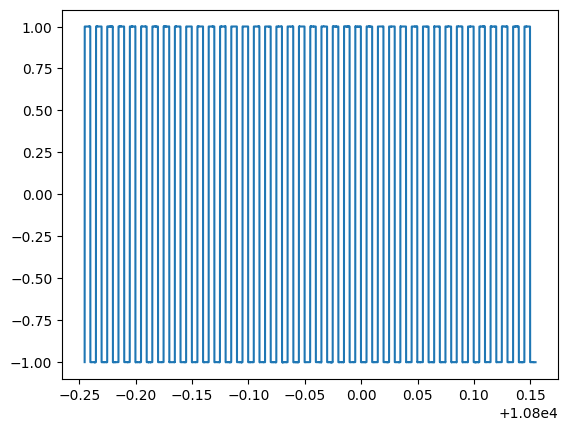

In [22]:
start, end = -10000, -1

plt.plot(t_atomic[start:end], y[start:end])

### The drift curve — what the run was really for

`np.diff(kept)` is scans per atomic second, second by second. That **is** the
board's clock measured against an atomic reference, and it is the plot worth
keeping from a long run.

In [ ]:
kept, dropped = clean_edges(edges, rate)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(np.arange(len(kept) - 1), np.diff(kept), lw=1)
ax.axhline(rate, color="k", ls="--", lw=1, label=f"nominal {rate:,.0f}")
ax.set_xlabel("atomic second"); ax.set_ylabel("scans / atomic second")
ax.legend(); ax.grid(alpha=0.3)

print(f"{len(dropped)} artefact(s) discarded: {dropped}")
print(f"clock error {report['ppm']:+.2f} ppm -> {report['seconds_per_day']:.2f} s/day")

---
# 7. Reference

**Configuring** — `daq.ai.setup(chans, rate=, duration=, trigger=)` ·
`daq.ao.setup(channels_role=, shape=, freq=, amp=, rate=, trigger=)` ·
`daq.pps.terminal(...)` · `daq.pps.counter(...)` · `daq.check(strict=)` ·
`daq.wiring()`

**Measuring** — `daq.ai.acquire()` · `daq.ai.acquire_chunks(duration=)` ·
`daq.acquire_with_pps()` · `daq.clock_check(seconds=)` · `ai0.trace()` ·
`daq.ai.time_axis()` · `daq.ai.atom_time_axis()`

**Generating** — `ao0.dc(v)` · `daq.ao.start()` / `.stop()` ·
`with daq.ao.generating(**overrides):` · `daq.ao.onboard()`

**Markers** — `daq.marker.terminal(...)` · `daq.marker.counter(...)` ·
`daq.marker.last_marks` · `daq.marker.n_marks()`. Collected by `long_run` into
`markers.i64`, and by `acquire_with_pps()` onto `last_marks`.

**Recording** — `daq.long_run(outdir, hours=, rotate_minutes=, background=)` ·
`run.status()` / `.alive` / `.stop()` · `daq.live_preview()` ·
`LiveScope(outdir, channel, width)`

**Reading** — `load_long_run` · `load_segment` · `iter_segments` · `load_run` ·
`load_markers` · `marker_times` · `trigger_time` · `edge_report` ·
`clean_edges` · `times_from_edges`

**The board itself** — `daq.pin_of(...)` · `daq.signal_at(...)` ·
`daq.nearest_ground(...)` · `daq.pinout()` · `daq.terminals()` ·
`daq.terminal_roles()`

# 8. When something goes wrong

| symptom | cause |
|---|---|
| an edit to the driver changes nothing | **restart the kernel** |
| ppm is enormous, `t_atomic` starts at 1.0 | same — stale kernel, edge cleaning not running |
| the live plot never updates | missing `clear_output`/`display`, or `plt.pause` on inline |
| the live waveform looks ragged | it is a decimated summary — use §5.3 or `LiveScope` |
| `gaps` is not 0 | `-200279` (PC too slow) or `-200361` (USB could not drain the board) |
| AO underflow `-200621` | `onboard()` was False — lower `ao.rate` or raise `ao.freq` |
| few or no 1 pps edges | check `daq.wiring()` |
| `FileExistsError` on `long_run` | that directory already holds a run |
| `KeyError: no segment N` | the message lists the segments that exist |
| overflow after adding a channel | the rate limit is **aggregate** — `daq.check()` does the arithmetic |
| no `markers.i64` in the run directory | `daq.marker.terminal` was never set — the file is only created on the first marker |
| a marker with no pulse under it | it arrived before the task armed. Send it from `daq.ai.set_on_armed(...)` |
| `marks[0]` is not 0 | the trigger and marker lines are different, so the trigger was not marked |

**Keep the raw output directory.** Every number here can be recomputed from it.